In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [226]:
import colossus.cosmology
from colossus.lss import bias as colossus_bias
cosmo = colossus.cosmology.cosmology.setCosmology("planck15")

bias_model = "sheth01"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

bias_model = "comparat17"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

1.254501032663919
1.2930499593363445
1.137078274795876
1.1740098587964916


In [5]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [6]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [7]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

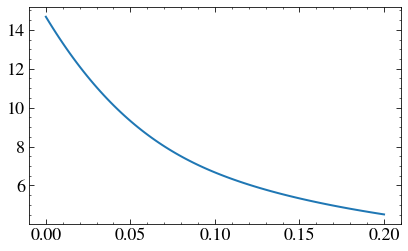

In [9]:
R=0.1
dx=2*R
nbins=100
r = np.linspace(0, dx, nbins)
xi = cf_lin(r)
plt.plot(r, xi)

In [12]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [13]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [14]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [496]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1.2
    bias_factor = bias_k**2
    
    mask = logk > -0.3
    bias_factor_k = np.full(len(logk), bias_factor)
    #bias_factor_k[mask] = bias_factor*0.5
    bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_factor_k*Pk - bias_factor_k*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

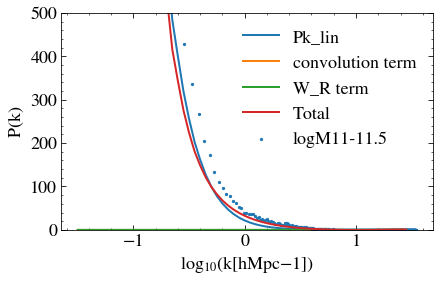

In [502]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

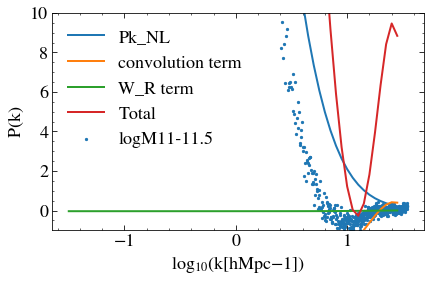

In [481]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.15
b_factor = b_const**2

plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -b_factor*kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Total")
plt.ylim(-1,1)
plt.ylim(-1,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

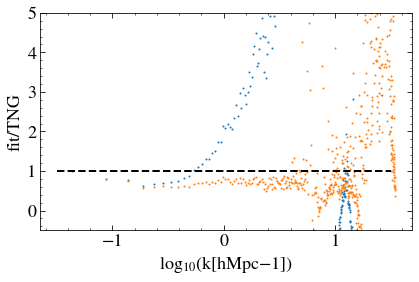

In [391]:
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

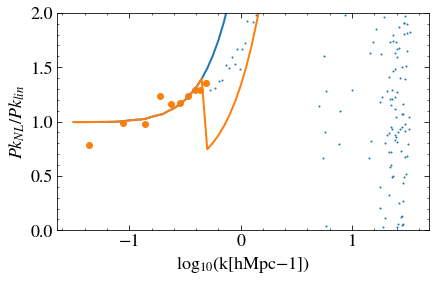

In [318]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")
ratio1 = Pnl(10**logks)/Plin(10**logks)
mask = logks>-0.3
ratio1[mask] = ratio1[mask]*0.5
plt.plot(logks, ratio1)
plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"),s=1)

plt.ylim(0,2)



#plt.plot(logks, Pnl(10**logks)/Plin(10**logks))
plt.ylabel("$Pk_{NL}/Pk_{lin}$")

plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

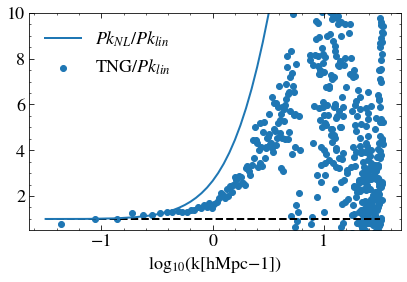

In [469]:
logk_tng = np.log10(Pk110["k"])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")
#ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(10**logk_tng)

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0.5,10)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

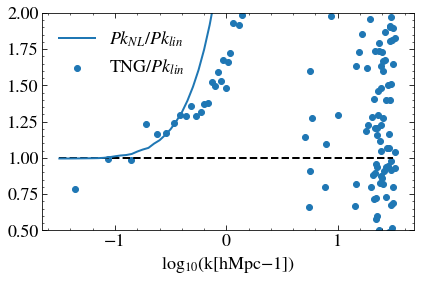

In [470]:
#ratio2[3] = Pnl(10**logk_tng[3])/Plin(10**logk_tng[3])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0.5,2)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

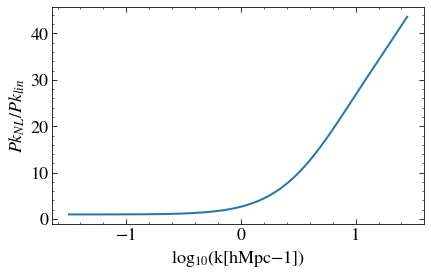

In [202]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")
ratio1 = Pnl(10**logks)/Plin(10**logks)
#plt.plot(logks, 1+15*(logks--0.2)**2)
#plt.ylim(0,5)



#plt.plot(logks, Pnl(10**logks)/Plin(10**logks))
plt.ylabel("$Pk_{NL}/Pk_{lin}$")

plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

In [410]:
def poly3(x, a, b, c, d, x0):
    return a + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3 

In [437]:
def poly2(x, a, b, c, x0):
    return a + b*(x-x0) + c*(x-x0)**2 

In [440]:
def poly1(x, a, b, c, x0):
    return a + b*(x-x0) 

In [402]:
def poly4(x, a, b, c, d, e, x0):
    return a + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3 + e*(x-x0)**4 

In [372]:
def scale_dependent_bias_exp(logk, a, b, c):
    bias_k = a*np.exp(b*logk + c*logk**2)
    return bias_k

In [348]:

from scipy.optimize import curve_fit
pop_fit1, pcov1 = curve_fit(poly3, logks,ratio1,maxfev = 4000, sigma=None)
    

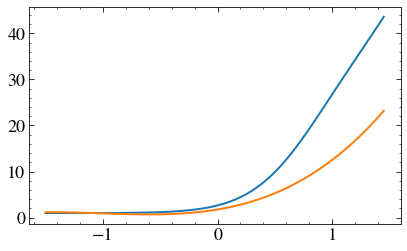

In [349]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")

plt.plot(logks, poly3(logks,*pop_fit1))

In [490]:

pop_fit1, pcov1 = curve_fit(poly3, np.log10(Pk110["k"][1:100]),ratio2[1:100],maxfev = 4000, sigma=None)
   

(0.0, 2.0)

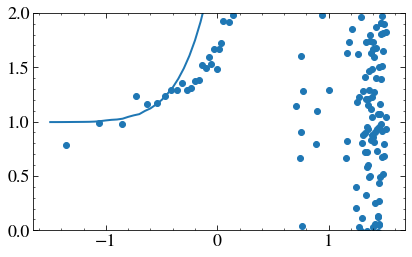

In [492]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0,2)

(0.0, 2.0)

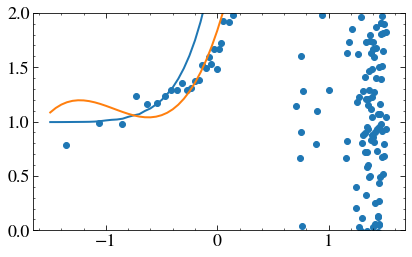

In [495]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")

plt.plot(logks, poly3(logks,*pop_fit1))
plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0,2)

In [414]:
a, b, c, d, x0 = pop_fit1

(0.0, 2.0)

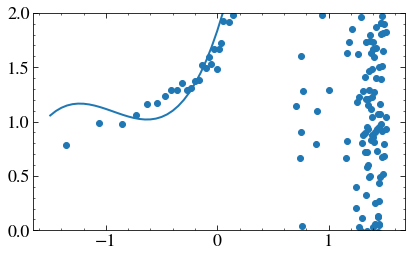

In [417]:
plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")
plt.plot(logks, poly3(logks,a, b, c, d, x0 ))
plt.ylim(0,2)

In [471]:
pop_fit_large, pcov1 = curve_fit(poly1, np.log10(Pk110["k"][0:20]),ratio2[0:20],maxfev = 4000, sigma=None)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/scipy/optimize/minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


(0.0, 2.0)

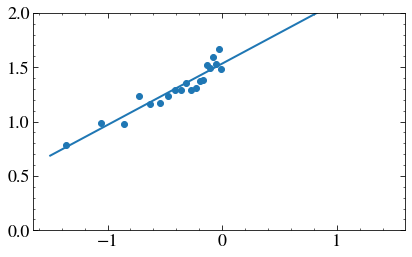

In [472]:
plt.scatter(np.log10(Pk110["k"][:20]),ratio2[:20], label="TNG/$Pk_{lin}$")
plt.plot(logks, poly1(logks,*pop_fit_large))
plt.ylim(0,2)

In [473]:
logks_insert = np.arange(-1.5, 0, 0.1)
ratio_insert = poly1(logks_insert,*pop_fit_large)

In [474]:
logk3 = np.concatenate((logks_insert,logk_tng))
ratio3 = np.concatenate((ratio_insert,ratio2))

(0.0, 2.0)

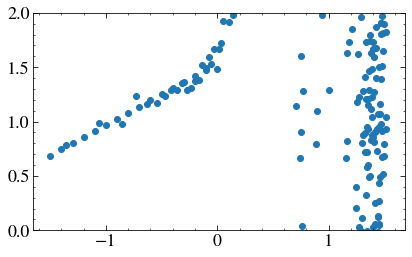

In [475]:
plt.scatter(logk3, ratio3)
plt.ylim(0,2)

In [476]:

pop_fit1, pcov1 = curve_fit(poly3, logk3[0:100],ratio3[0:100],maxfev = 4000, sigma=None)
   

(0.0, 2.0)

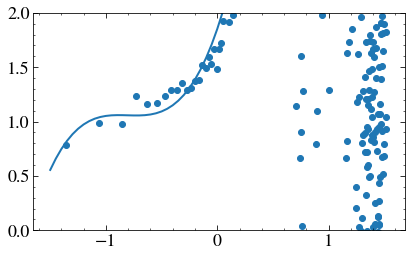

In [479]:
plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")
plt.plot(logks, poly3(logks,*pop_fit1))
plt.ylim(0,2)